In [1]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import time
import os
import matplotlib.pyplot as plt



In [2]:
# Step 1: Mount Google Drive (already done, but included for completeness)
# drive.mount('/content/drive')

# Define paths
base_dir = '/content/drive/My Drive/outputs'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')



In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Step 3: Set up ImageDataGenerator for preprocessing and augmentation
IMG_SIZE = (299, 299)
BATCH_SIZE = 32

# Training: Normalize and augment
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)


# Validation and Testing: Only normalize
val_test_datagen = ImageDataGenerator(rescale=1./255)

In [5]:
# Step 4: Create data generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',  # Binary classification
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

Found 736 images belonging to 2 classes.
Found 77 images belonging to 2 classes.
Found 238 images belonging to 2 classes.


In [8]:
# Define the CNN model
inputs = Input(shape=(299, 299, 3))
x = Conv2D(32, (3, 3), activation='relu')(inputs)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation='relu')(x)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(128, (3, 3), activation='relu')(x)
x = MaxPooling2D((2, 2))(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs=inputs, outputs=outputs)


# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model summary
model.summary()

EPOCHS = 30

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 297, 297, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 148, 148, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 146, 146, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 73, 73, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 71, 71, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 35, 35, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 156800)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    20,070,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,163,905 (76.92 MB)

 Trainable params: 20,163,905 (76.92 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Train the model
start_time = time.time()
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
)
end_time = time.time()

# Calculate training time
training_time = end_time - start_time
print(f"Total Training Time: {training_time:.2f} seconds")
print(f"Average Time per Epoch: {training_time / len(history.history['loss']):.2f} seconds")



Epoch 1/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 167s 7s/step - accuracy: 0.4842 - loss: 1.0482 - val_accuracy: 0.5844 - val_loss: 0.6949
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 847ms/step - accuracy: 0.4827 - loss: 0.6941 - val_accuracy: 0.4286 - val_loss: 0.6939
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 912ms/step - accuracy: 0.5051 - loss: 0.6934 - val_accuracy: 0.5455 - val_loss: 0.6931
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 851ms/step - accuracy: 0.4962 - loss: 0.6931 - val_accuracy: 0.4156 - val_loss: 0.6935
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 903ms/step - accuracy: 0.5113 - loss: 0.6928 - val_accuracy: 0.5584 - val_loss: 0.6933
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 844ms/step - accuracy: 0.5100 - loss: 0.6931 - val_accuracy: 0.4286 - val_loss: 0.6944
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 898ms/step - accuracy: 0.5188 - loss: 0.6926 - val_accuracy: 0.3896 - val_loss: 0.6937
Epoch 8/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 840ms/step - accuracy: 0.4523 - loss: 0.6936 - val_accura

In [10]:
# Save training history

model.save(os.path.join(base_dir, 'cnn_binary_classification_model.h5'))

# Print final performance
print("\nFinal Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])
print("Final Training Loss:", history.history['loss'][-1])
print("Final Validation Loss:", history.history['val_loss'][-1])


Final Training Accuracy: 0.5570651888847351
Final Validation Accuracy: 0.5064935088157654
Final Training Loss: 0.6814684867858887
Final Validation Loss: 0.7169026732444763


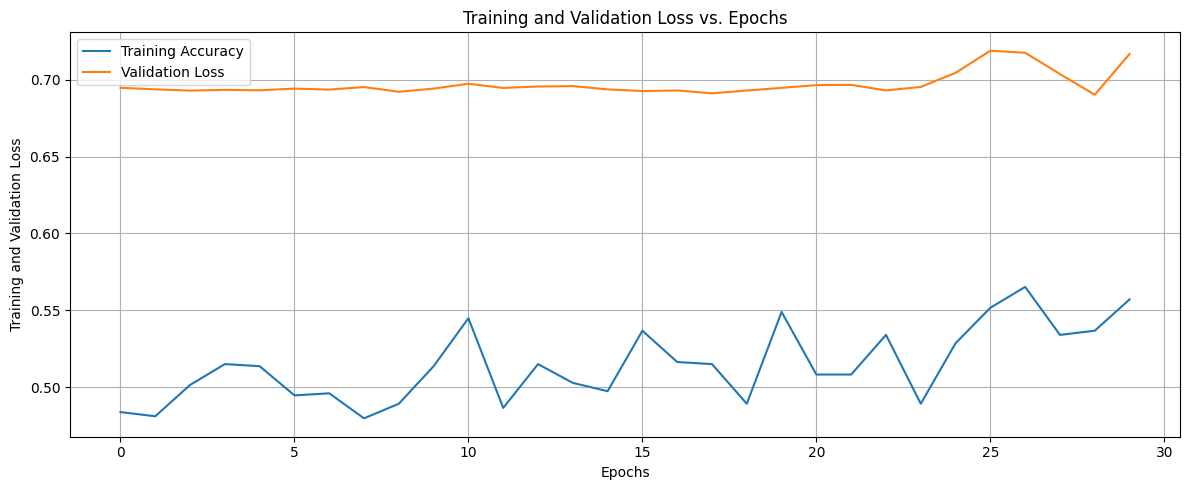

In [11]:
# Step 1: Plot accuracy and loss
plt.figure(figsize=(12, 5))

# Training Accuracy vs Validation Loss plot
plt.subplot(1, 1, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
# plt.savefig(plot_path_acc_loss)
plt.show()


Found 238 images belonging to 2 classes.


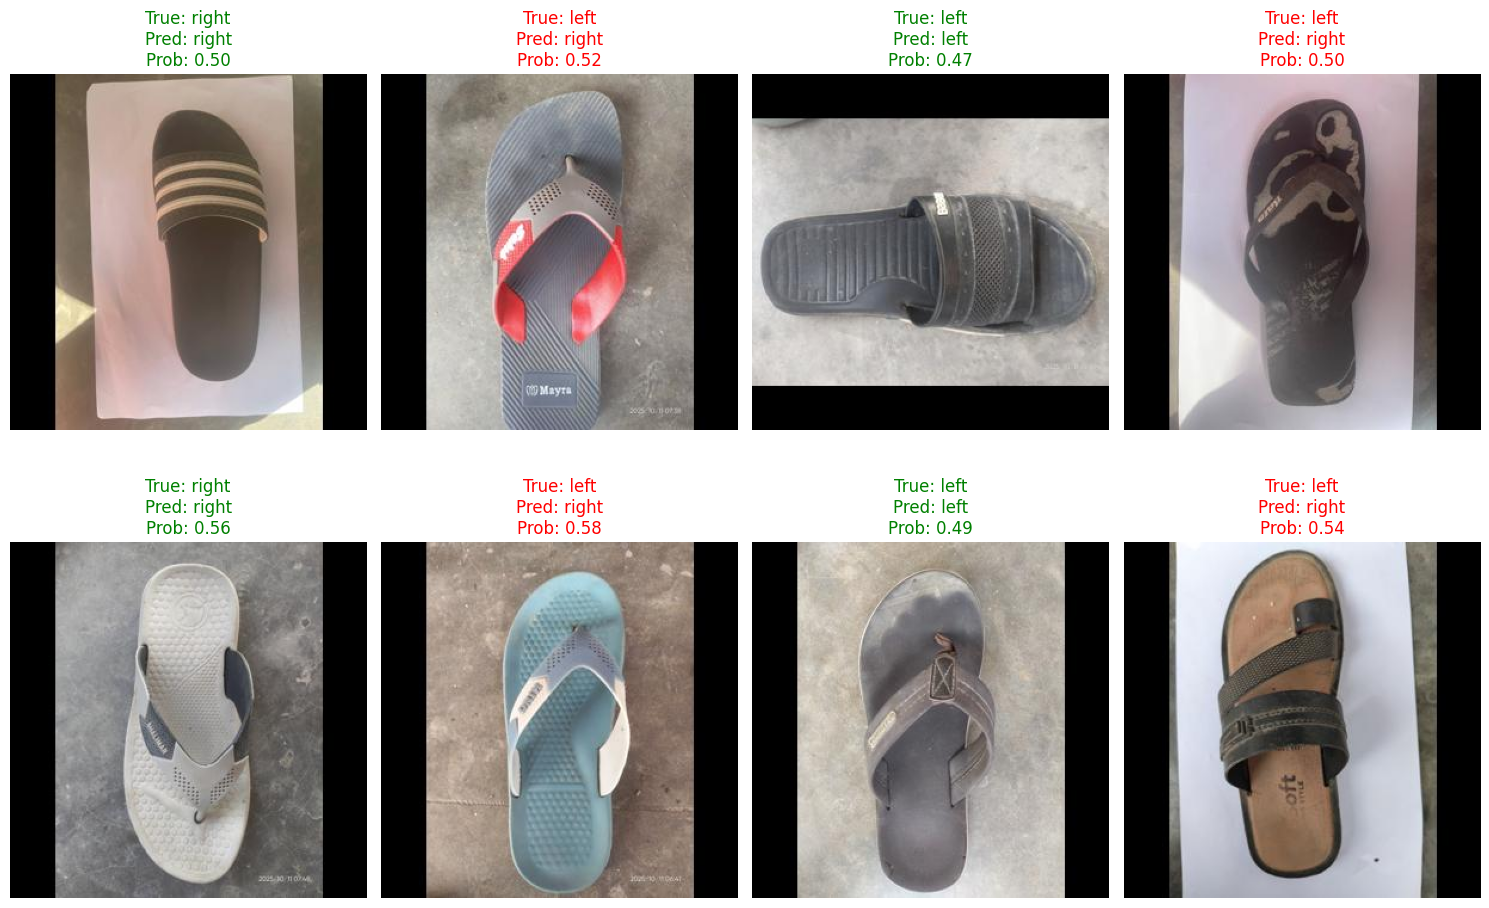

In [13]:
# Step 2: Visualize test predictions
IMG_SIZE = (299, 299)
BATCH_SIZE = 32

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    os.path.join(base_dir, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

# Load model
# model = tf.keras.models.load_model(model_path)

# Get class names
class_names = list(test_generator.class_indices.keys())

# Get 8 test samples
test_generator.reset()
images, true_labels = next(test_generator)
predictions = model.predict(images, verbose=0)
pred_labels = (predictions > 0.5).astype(int).flatten()
probabilities = predictions.flatten()

# Plot 8 samples
plt.figure(figsize=(15, 10))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i])
    true_label = class_names[int(true_labels[i])]
    pred_label = class_names[pred_labels[i]]
    prob = probabilities[i]
    title = f'True: {true_label}\nPred: {pred_label}\nProb: {prob:.2f}'
    plt.title(title, color='green' if true_label == pred_label else 'red')
    plt.axis('off')
plt.tight_layout()
# plt.savefig(plot_path_test_samples)
plt.show()